In [39]:
import pandas as pd

# 1 - Importar a base de dados
tabela = pd.read_csv("pred_solar.csv")
tabela = tabela.dropna()
display(tabela)
display(tabela.info())

,ano,mes,dia,hora,cloud_max,cloud_sum,cloud_layers,chuva,vis,temp,prod
0,2024,10,10,0,6.0,12.3,3,0,9999,22.0,0.0
1,2024,10,10,1,6.0,12.3,3,0,9999,22.0,0.0
2,2024,10,10,2,3.6,5.4,2,0,9999,23.0,0.0
3,2024,10,10,3,3.6,5.4,2,0,9999,22.0,0.0
4,2024,10,10,4,6.0,9.6,2,0,9999,22.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
7323,2025,8,31,19,3.6,6.6,3,0,9999,25.0,276.2
7324,2025,8,31,20,3.6,6.6,3,0,9999,24.0,51.5
7325,2025,8,31,21,3.6,6.6,3,0,8000,23.0,0.0
7326,2025,8,31,22,3.6,7.2,3,0,9999,23.0,0.0


<class 'pandas.DataFrame'>
Index: 7225 entries, 0 to 7327
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ano           7225 non-null   int64  
 1   mes           7225 non-null   int64  
 2   dia           7225 non-null   int64  
 3   hora          7225 non-null   int64  
 4   cloud_max     7225 non-null   float64
 5   cloud_sum     7225 non-null   float64
 6   cloud_layers  7225 non-null   int64  
 7   chuva         7225 non-null   int64  
 8   vis           7225 non-null   int64  
 9   temp          7225 non-null   float64
 10  prod          7225 non-null   float64
dtypes: float64(4), int64(7)
memory usage: 677.3 KB


None

In [43]:
from sklearn.preprocessing import LabelEncoder

x = tabela.drop(columns="prod")
y = tabela["prod"]

from sklearn.model_selection import train_test_split

x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.3)

print("Treino:", len(x_treino))
print("Teste :", len(x_teste))

Treino: 5057
Teste : 2168


In [47]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

# 2 - Criar a IA
modelo_arvoredecisao = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
modelo_knn = KNeighborsRegressor(
    n_neighbors=5
)

# 3 - Treinar a IA
modelo_arvoredecisao.fit(x_treino, y_treino)
modelo_knn.fit(x_treino, y_treino)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


In [50]:
previsao_arvoredecisao = modelo_arvoredecisao.predict(x_teste)
previsao_knn = modelo_knn.predict(x_teste)

from sklearn.metrics import r2_score

display(r2_score(y_teste, previsao_arvoredecisao))
display(r2_score(y_teste, previsao_knn))

0.9023928942532761

0.8588000430426428

In [55]:
tabela_nc = pd.read_csv("pred_solar_teste.csv")
tabela_nc_teste = tabela_nc.drop(columns=["prod"], errors="ignore")
display(tabela_nc_teste)

# Fazer as previsões - modelo_arvoredecisao
tabela_nc_teste["prod"] = modelo_arvoredecisao.predict(tabela_nc_teste)
display(tabela_nc_teste)

,ano,mes,dia,hora,cloud_max,cloud_sum,cloud_layers,chuva,vis,temp
0,2025,9,1,0,3.6,4.5,2,0,9999,22
1,2025,9,1,1,3.6,4.5,2,0,9999,22
2,2025,9,1,2,2.1,4.2,2,0,8000,21
3,2025,9,1,3,2.1,6.0,3,0,8000,21
4,2025,9,1,4,2.1,6.0,3,0,8000,20
...,...,...,...,...,...,...,...,...,...,...
208,2025,9,9,19,0.0,0.0,0,0,10000,26
209,2025,9,9,20,0.0,0.0,0,0,10000,25
210,2025,9,9,21,0.0,0.0,0,0,10000,24
211,2025,9,9,22,0.0,0.0,0,0,10000,23


,ano,mes,dia,hora,cloud_max,cloud_sum,cloud_layers,chuva,vis,temp,prod
0,2025,9,1,0,3.6,4.5,2,0,9999,22,0.000
1,2025,9,1,1,3.6,4.5,2,0,9999,22,0.000
2,2025,9,1,2,2.1,4.2,2,0,8000,21,0.000
3,2025,9,1,3,2.1,6.0,3,0,8000,21,0.000
4,2025,9,1,4,2.1,6.0,3,0,8000,20,0.000
...,...,...,...,...,...,...,...,...,...,...,...
208,2025,9,9,19,0.0,0.0,0,0,10000,26,367.213
209,2025,9,9,20,0.0,0.0,0,0,10000,25,22.264
210,2025,9,9,21,0.0,0.0,0,0,10000,24,0.000
211,2025,9,9,22,0.0,0.0,0,0,10000,23,0.000


RESULTADOS DO MODELO
R²   : 0.9204
MAE  : 116.13
RMSE : 238.34


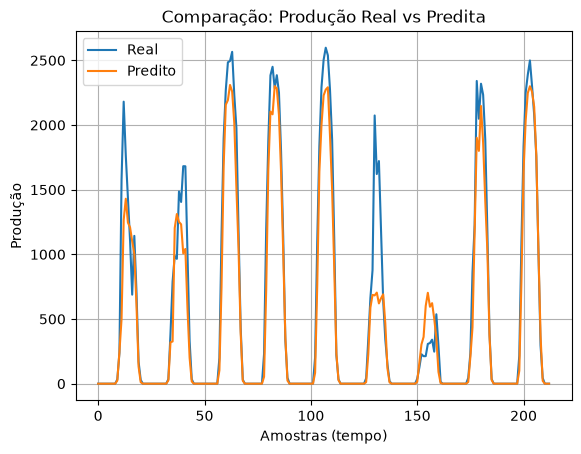

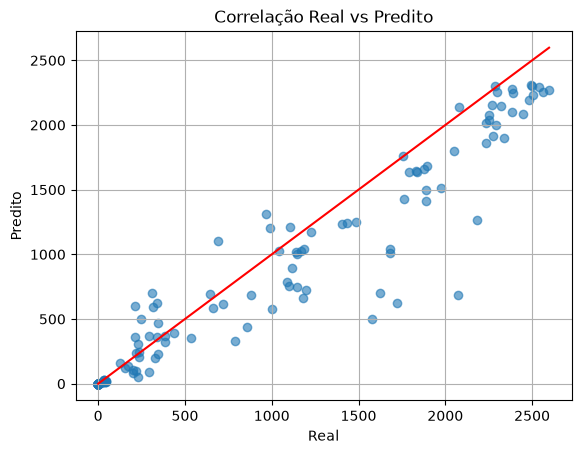

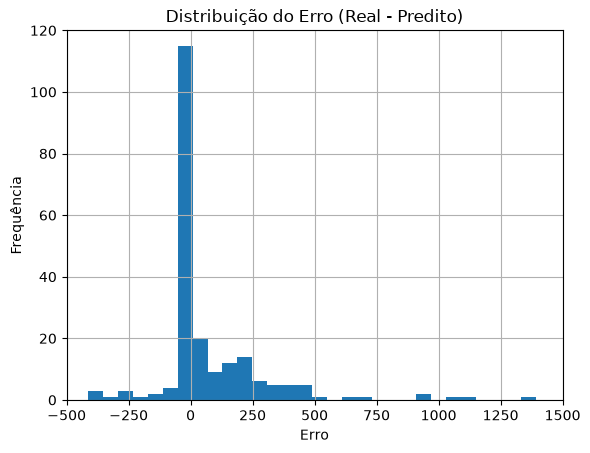

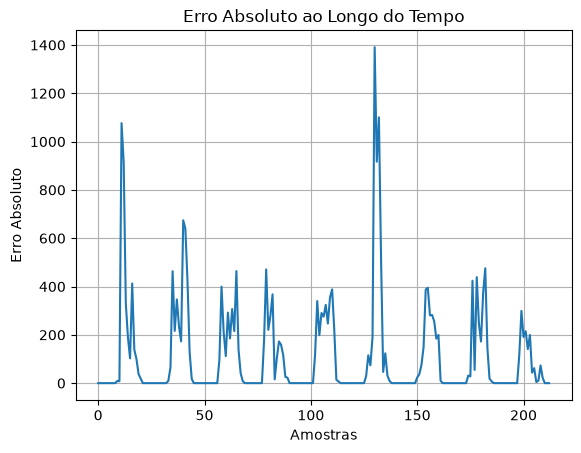


ESTATÍSTICAS DO ERRO:
Erro médio absoluto: 116.13
Erro máximo: 1391.10
Erro mínimo: 0.00


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ======================================================
# CARREGAR DADOS
# ======================================================

tabela_real = tabela_nc
tabela_pred = tabela_nc_teste

y_real = tabela_real["prod"].values
y_pred = tabela_pred["prod"].values

# ======================================================
# MÉTRICAS
# ======================================================

r2 = r2_score(y_real, y_pred)
mae = mean_absolute_error(y_real, y_pred)
rmse = np.sqrt(mean_squared_error(y_real, y_pred))

print("====================================")
print("RESULTADOS DO MODELO")
print("====================================")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print("====================================")

# ======================================================
# DATAFRAME DE ANÁLISE
# ======================================================

resultado = tabela_real.copy()
resultado["prod_pred"] = y_pred
resultado["erro"] = y_real - y_pred
resultado["erro_abs"] = np.abs(resultado["erro"])

# ======================================================
# 1 - GRÁFICO: REAL vs PREVISTO (linha temporal)
# ======================================================

plt.figure()
plt.plot(y_real, label="Real")
plt.plot(y_pred, label="Predito")
plt.title("Comparação: Produção Real vs Predita")
plt.xlabel("Amostras (tempo)")
plt.ylabel("Produção")
plt.legend()
plt.grid()
plt.show()

# ======================================================
# 2 - GRÁFICO: DISPERSÃO (correlação)
# ======================================================

plt.figure()
plt.scatter(y_real, y_pred, alpha=0.6)
plt.plot([min(y_real), max(y_real)],
         [min(y_real), max(y_real)],
         color="red")
plt.title("Correlação Real vs Predito")
plt.xlabel("Real")
plt.ylabel("Predito")
plt.grid()
plt.show()

# ======================================================
# 3 - GRÁFICO: DISTRIBUIÇÃO DO ERRO
# ======================================================

plt.figure()
plt.hist(resultado["erro"], bins=30)
plt.title("Distribuição do Erro (Real - Predito)")
plt.xlabel("Erro")
plt.ylabel("Frequência")
plt.xlim(-500, 1500)
plt.ylim(0, 120)
plt.grid()
plt.show()

# ======================================================
# 4 - GRÁFICO: ERRO ABSOLUTO AO LONGO DO TEMPO
# ======================================================

plt.figure()
plt.plot(resultado["erro_abs"])
plt.title("Erro Absoluto ao Longo do Tempo")
plt.xlabel("Amostras")
plt.ylabel("Erro Absoluto")
plt.grid()
plt.show()

# ======================================================
# ESTATÍSTICAS EXTRAS
# ======================================================

print("\nESTATÍSTICAS DO ERRO:")
print(f"Erro médio absoluto: {resultado['erro_abs'].mean():.2f}")
print(f"Erro máximo: {resultado['erro_abs'].max():.2f}")
print(f"Erro mínimo: {resultado['erro_abs'].min():.2f}")